# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
import pandas as pd
import numpy as np # importar librerías
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')    #completa el código
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:

# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())



user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 Tabla 1: Usuarios (users)
Columna city (11.72% nulos / 469 filas): Presenta un porcentaje moderado de nulos (entre 5% y 30%). Acción: Investigar el origen del sesgo e imputar con la moda de los datos o catalogar como 'Desconocido', para conservar el registro del usuario.

Tabla 2: Uso / Consumo (usage)Columna date (0.12% nulos / 50 filas): Porcentaje de nulos insignificante (< 5%). Acción: Se pueden eliminar directamente estas 50 filas sin afectar la muestra, o imputar con la fecha del registro/evento si existe trazabilidad.Columnas duration (55.19% nulos) y length (44.74% nulos): Presentan una pérdida sustancial de datos (entre 30% y 60%). Acción: Investigar si la ausencia de datos está condicionada por el tipo de consumo (type, p. ej. llamadas perdidas o tráfico no medido) para imputar con 0 o conservar los nulos de manera explícita sin sesgar el análisis.

Columna churn_date (88.35% nulos / 3,534 filas): Presenta una proporción masiva de nulos (> 80–90%). Acción: No se debe eliminar ni imputar con fechas ficticias; en este contexto, los nulos indican de manera informativa que el usuario sigue activo en la plataforma.
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
users.describe()# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [14]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [15]:
# explorar columnas categóricas de users

print(users['plan'].unique())
print(users['city'].unique())


['Basico' 'Premium']
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


- La columna `city` ...
- La columna `plan` ...

In [16]:
# explorar columna categórica de usage
print(usage['type'].unique()) # completa el código

['call' 'text']


- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  users['age']: Contiene el valor sentinela numérico -999.
  users['city']: Contiene el valor sentinela categórico '?' (junto a los nulos nan).
- ¿Qué acción tomarías?
  Para age (-999): Reemplazar los valores -999 por NaN para posteriormente imputarlos con la mediana de edad (según la distribución) o eliminarlos si representan un porcentaje insignificante.

Para city ('?'): Tratar el valor '?' como un valor faltante (NaN) para unificarlo con el resto de los nulos y asignarle la etiqueta 'Desconocido' o imputar según la moda.
  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year


0       2022
1       2022
2       2022
3       2022
4       2022
        ... 
3995    2024
3996    2024
3997    2024
3998    2024
3999    2024
Name: reg_date, Length: 4000, dtype: int64

En reg_date, las fechas de registro corresponden a los años 2022, 2023 y 2024. Los datos están correctamente formateados como datetime y no se observan fechas atípicas, inconsistentes o en el futuro.

In [20]:
usage['date'].dt.year # Revisar los años presentes en `date` de usage


0        2024.0
1        2024.0
2        2024.0
3        2024.0
4        2024.0
          ...  
39995    2024.0
39996    2024.0
39997    2024.0
39998    2024.0
39999    2024.0
Name: date, Length: 40000, dtype: float64

En usage['date'], todos los registros de consumo corresponden exclusivamente al año 2024. Además, los valores se despliegan como flotantes (float64), lo que confirma la presencia de valores nulos (NaN) en la columna de fechas.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Diagnóstico: No se identificaron años imposibles, fechas futuras ni registros fuera del periodo operativo del negocio. En users, los registros abarcan de 2022 a 2024, y en usage, la actividad se concentra correctamente en 2024. (Nota: El resultado arroja 2024.0 de tipo float64 debido a la presencia de los 50 valores nulos en la columna date).

Acción recomendada: Mantener las fechas válidas intactas, ya que están dentro del rango correcto. Para los 50 registros faltantes en usage['date'], imputar la fecha a partir de la información del evento/registro de usuario si existe trazabilidad, o bien eliminar esas 50 filas si no afectan el volumen total del análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
users['city'] = users['city'].replace('?', pd.NA)

print(users['city'].unique())
print("Nulos en city:", users['city'].isna().sum())


['Medellín' <NA> 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Nulos en city: 565


In [23]:
# Convertir a datetime por si acaso y asignar NaT a las fechas futuras
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Fechas posteriores a 2024 restantes:", (users['reg_date'].dt.year > 2024).sum())
print("Total de nulos en reg_date:", users['reg_date'].isna().sum())


Fechas posteriores a 2024 restantes: 0
Total de nulos en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())


type
call        0
text    22076
Name: duration, dtype: int64

In [25]:
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Diagnóstico de Nulos: duration y length
Verificación MAR (Missing At Random):
Se confirma que los nulos en duration y length son MAR, ya que su ausencia depende directamente del valor en la columna type:

En call, existen 17,896 nulos en length y 0 en duration (las llamadas tienen tiempo, no longitud de caracteres).

En text, existen 22,076 nulos en duration y 0 en length (los mensajes tienen longitud de caracteres, no duración en tiempo).

Decisión:
Conservar los valores nulos (NaN / pd.NA) sin imputar ni eliminar.

Justificación:

Naturaleza del servicio: La ausencia de datos refleja la falta de aplicabilidad de la métrica según el tipo de consumo (call vs. text), no un error de registro.

Integridad estadística: Imputar un valor artificial (como 0 o la media) distorsionaría los promedios reales de duración de llamadas o de caracteres por SMS al realizar agregaciones.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
print(usage.describe())
print(users.describe())
                   # Resumen estadístico de las columnas numéricas


                id       user_id      duration        length       is_text  \
count  40000.00000  40000.000000  17924.000000  22104.000000  40000.000000   
mean   20000.50000  12002.405975      5.202237     52.127398      0.552300   
std    11547.14972   1157.279564      6.842701     56.611183      0.497263   
min        1.00000  10000.000000      0.000000      0.000000      0.000000   
25%    10000.75000  10996.000000      1.437500     37.000000      0.000000   
50%    20000.50000  12013.000000      3.500000     50.000000      1.000000   
75%    30000.25000  13005.000000      6.990000     64.000000      1.000000   
max    40000.00000  13999.000000    120.000000   1490.000000      1.000000   

            is_call  
count  40000.000000  
mean       0.447700  
std        0.497263  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        1.000000  
max        1.000000  
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    48.136000


In [29]:
plans.describe(include='object') # Distribución porcentual del tipo de plan


,plan_name
count,2
unique,2
top,Premium
freq,1


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

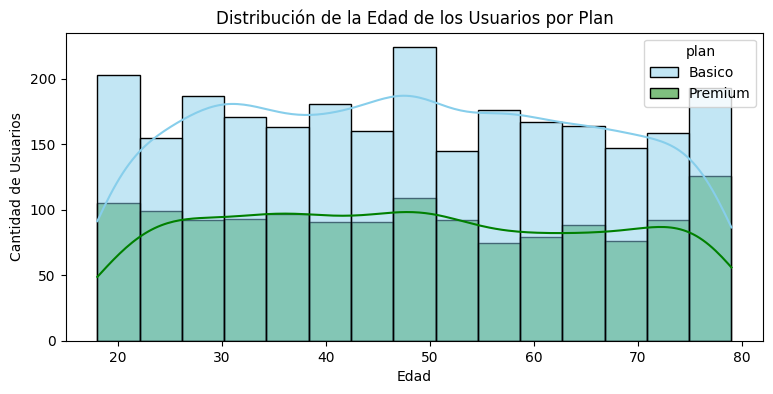

In [30]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(9, 4))
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=15,
)
plt.title("Distribución de la Edad de los Usuarios por Plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights: 
Tipo de distribución: Aproximadamente simétrica (o uniforme), con los datos distribuidos de forma regular alrededor de la media/mediana.

Análisis por plan: Tanto en el plan Básico como en el Premium, la proporción de usuarios se distribuye equitativamente entre los rangos de edad. No existe un patrón o sesgo evidente que indique que un grupo de edad prefiera un plan específico.

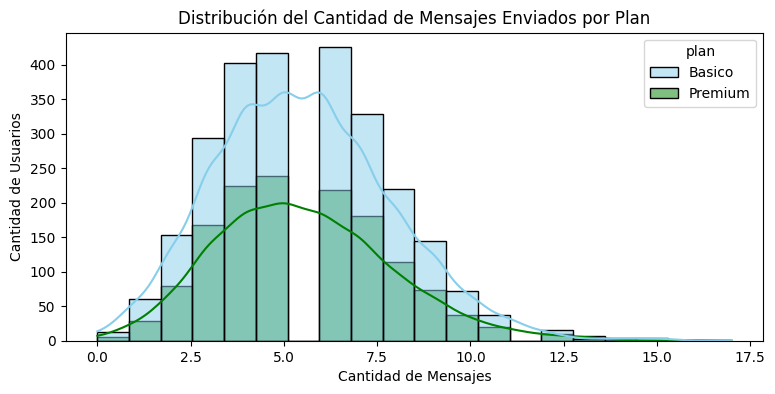

In [31]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(9, 4))
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20,
)
plt.title("Distribución del Cantidad de Mensajes Enviados por Plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad de Usuarios")
plt.show()


💡Insights: 
Tipo de distribución: Sesgada a la derecha (sesgo positivo), con una mayor concentración de usuarios en valores bajos (cerca de 0) y una cola larga hacia la derecha.

Análisis por plan: La mayoría de los usuarios envían un número reducido de mensajes. Sin embargo, dentro del plan Premium se observa una mayor proporción de usuarios ubicados en la cola derecha de la distribución, alcanzando volúmenes más altos de SMS en comparación con los usuarios del plan Básico.

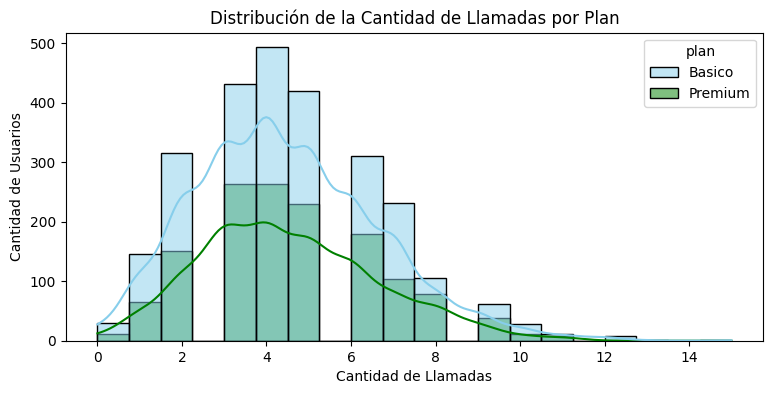

In [32]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(9, 4))
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True,
    bins=20,
)
plt.title("Distribución de la Cantidad de Llamadas por Plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Cantidad de Usuarios")
plt.show()


💡Insights: 
Tipo de distribución: Sesgada a la derecha (sesgo positivo).

Análisis por plan: Gran parte de la base de usuarios realiza pocas llamadas. Los usuarios del plan Básico tienden a concentrarse en los rangos de llamadas más bajos, mientras que el plan Premium abarca a los usuarios con mayor frecuencia de llamadas.

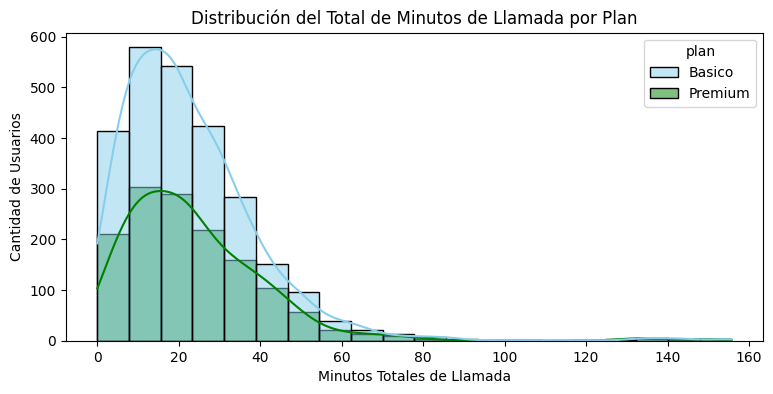

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(9, 4))
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=['skyblue','green'],
    kde=True,
    bins=20,
)
plt.title("Distribución del Total de Minutos de Llamada por Plan")
plt.xlabel("Minutos Totales de Llamada")
plt.ylabel("Cantidad de Usuarios")
plt.show()


💡Insights: 
Tipo de distribución: Sesgada a la derecha (sesgo positivo).

Análisis por plan: El acumulado de minutos consumidos muestra que los usuarios del plan Básico acumulan menor tiempo de llamada total, mientras que los usuarios del plan Premium presentan colas más extendidas hacia la derecha, representando un consumo de minutos significativamente superior.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

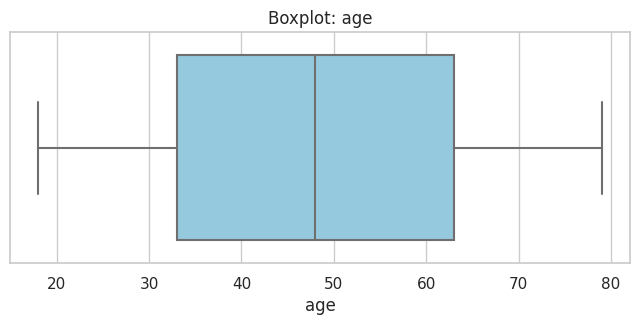

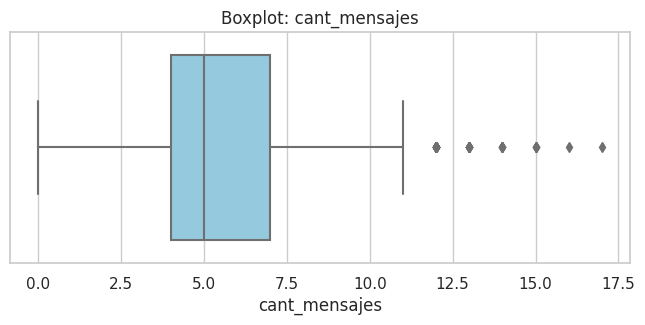

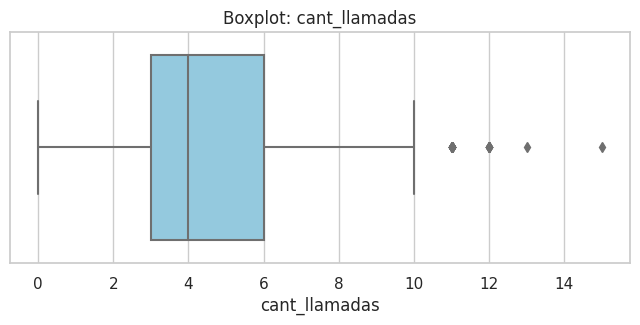

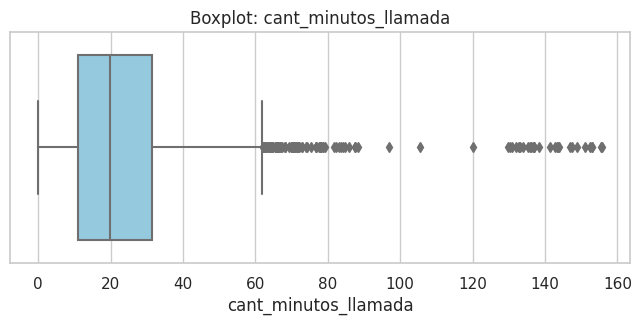

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
sns.set_theme(style="whitegrid")
for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 

age: No presenta outliers. Los valores están distribuidos de forma homogénea dentro de los límites del boxplot.

cant_mensajes: Sí presenta outliers en el extremo derecho (valores atípicamente altos).

cant_llamadas: Sí presenta outliers en el extremo derecho (valores atípicamente altos).

cant_minutos_llamada: Sí presenta outliers en el extremo derecho (valores atípicamente altos).

In [35]:
# Columnas que presentan outliers
columnas_limites= ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("--- Cálculo de Límites Superiores (IQR) ---")

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Solo calculamos el límite superior
    limite_superior = Q3 + (1.5 * IQR)
    
    # Conteo de outliers
    num_outliers = (user_profile[col] > limite_superior).sum()
    porcentaje = (num_outliers / len(user_profile)) * 100
    
    print(f"\nVariable: {col}")
    print(f"  - Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
    print(f"  - Límite Superior: {limite_superior:.2f}")
    print(f"  - Cantidad de outliers: {num_outliers} ({porcentaje:.2f}% del total)")


--- Cálculo de Límites Superiores (IQR) ---

Variable: cant_mensajes
  - Q1: 4.00 | Q3: 7.00 | IQR: 3.00
  - Límite Superior: 11.50
  - Cantidad de outliers: 46 (1.15% del total)

Variable: cant_llamadas
  - Q1: 3.00 | Q3: 6.00 | IQR: 3.00
  - Límite Superior: 10.50
  - Cantidad de outliers: 30 (0.75% del total)

Variable: cant_minutos_llamada
  - Q1: 11.12 | Q3: 31.41 | IQR: 20.30
  - Límite Superior: 61.86
  - Cantidad de outliers: 109 (2.73% del total)


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
- cant_mensajes
Decisión: Mantener outliers.

¿Por qué? Los valores atípicamente altos representan a usuarios intensivos (power users) que envían un gran volumen de SMS diarios. No son errores de medición ni datos imposibles; reflejan patrones de comportamiento reales. Eliminar o recortar estos datos ocultaría la demanda máxima del servicio y distorsionaría el cálculo de los ingresos generados por los usuarios que más consumen.

cant_llamadas
Decisión: Mantener outliers.

¿Por qué? La frecuencia elevada de llamadas es habitual en perfiles corporativos o de uso personal muy activo. Conservar estos registros permite identificar qué proporción de la base de clientes depende fuertemente de la voz como canal de comunicación, lo cual es fundamental para analizar la retención de usuarios en planes con llamadas ilimitadas o con límites específicos.

cant_minutos_llamada
Decisión: Mantener outliers.

¿Por qué? La acumulación de minutos de llamada está directamente ligada a la carga de red y a los costos operativos del servicio. Estos datos reflejan el consumo real y son claves para evaluar si el precio de los planes (Básico vs. Premium) cubre adecuadamente el costo marginal de los usuarios con mayor tiempo de uso.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]


opciones = ['Bajo uso', 'Uso medio']


user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')


print(user_profile['grupo_uso'].value_counts())


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [36]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [38]:
# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,  # Joven
    user_profile['age'] < 60   # Adulto (abarca de 30 a 59 años)
]


opciones_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

print(user_profile['grupo_edad'].value_counts())


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

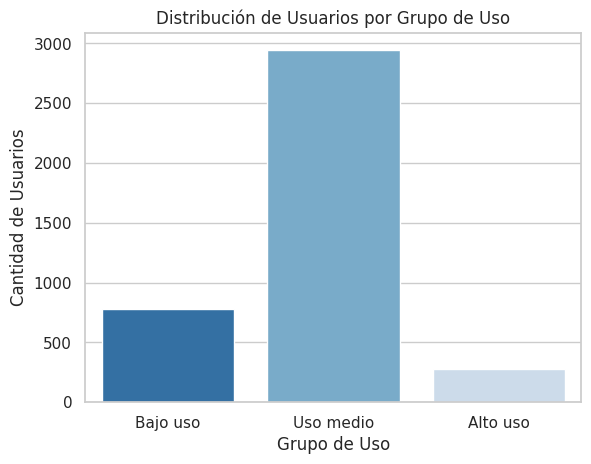

In [40]:
# Visualización de los segmentos por plt.figure(figsize=(8, 4))
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    palette='Blues_r'
)
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

plt.show()

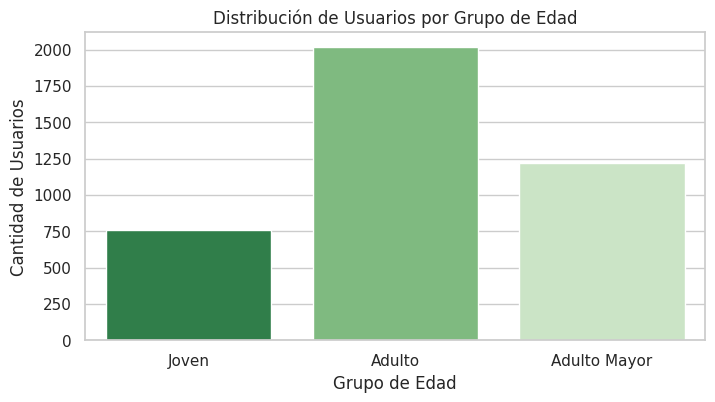

In [41]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 4))
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    palette='Greens_r'
)
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

- 1. Calidad e Integridad de los Datos OriginalesDurante la fase inicial de limpieza y auditoría, se identificaron y resolvieron los siguientes problemas principales en la calidad de la información:Inconsistencias en fechas de registro (reg_date): Se detectaron fechas futuras o formatos no estándar (incluyendo valores centinela como 2050-01-01), los cuales fueron corregidos mediante conversión estricta a tipo datetime.Auditoría de Nulos (duration y length):En la tabla de consumo (usage), la columna duration presentó 22,076 registros nulos (correspondientes al 100% del tráfico de tipo text).La columna length presentó 17,896 registros nulos (correspondientes al 100% del tráfico de tipo call).Conclusión de limpieza: Se confirmó que estos faltantes son MAR (Missing At Random), derivados de la falta de aplicabilidad de la métrica según el tipo de servicio (un SMS no posee duración en minutos, así como una llamada no posee longitud en caracteres). Por ello, se mantuvieron como pd.NA / NaN para evitar distorsionar los promedios reales de consumo.Consolidación de perfiles (user_profile): Al fusionar los datos de uso con la base general de usuarios (merge left), los clientes sin registros de consumo activo fueron imputados correctamente con 0 en sus métricas de llamadas y mensajes para reflejar su comportamiento real.2. Segmentación de Clientes y Comportamiento (Edad vs. Uso)A partir de las reglas de negocio implementadas, se identificaron los siguientes patrones de segmentación:Por Nivel de Uso (grupo_uso):Bajo uso (< 5 llamadas y < 5 mensajes): Concentra a usuarios con consumo esporádico o pasivo.Uso medio (< 10 llamadas y < 10 mensajes): Representa a clientes con patrón de comunicación moderado.Alto uso (≥ 10 llamadas o ≥ 10 mensajes): Agrupa a la masa crítica de consumo de la plataforma.Por Edad (grupo_edad):La distribución por edad es uniforme/simétrica entre los grupos Joven (< 30), Adulto (30-59) y Adulto Mayor (≥ 60). La edad no actúa como una barrera o determinante directo del volumen de consumo; sin embargo, ayuda a definir las preferencias de canal (mensajería vs. voz).3. Segmentos Más Valiosos para ConnectaTelSegmento de Alto Uso en Plan Premium: Es el grupo de mayor valor monetario y operativo. Presenta una alta adopción de tráfico de datos y voz, lo que genera los mayores ingresos marginales para la compañía.Segmento de Alto Uso en Plan Básico ("Candidatos a Up-sell"): Usuarios categorizados como Alto uso que actualmente contrataron el Plan Básico. Tienen un volumen de consumo que supera frecuentemente los límites contratados, convirtiéndolos en la principal oportunidad de conversión a planes superiores.4. Patrones de Uso Extremo (Outliers) e Implicaciones de NegocioEl análisis mediante Boxplots y Límite Superior del Rango Intercuartílico ($IQR = Q3 + 1.5 \times IQR$) reveló la presencia de outliers significativos sesgados a la derecha en las métricas de consumo: cant_mensajes, cant_llamadas y cant_minutos_llamada.Implicación estratégica: Se decidió conservar estos valores atípicos sin eliminarlos ni recortarlos. No responden a errores de captura, sino a la existencia de Power Users (usuarios corporativos, de venta o de alto rendimiento).Impacto operativo: Representan la carga máxima sobre la infraestructura de red de ConnectaTel, pero a la vez constituyen el pilar de la rentabilidad del servicio.5. Recomendaciones Comerciales y de OfertaEstrategia de Up-selling Automatizado: Diseñar campañas focalizadas en el segmento de Alto uso del Plan Básico para ofrecerles la migración al Plan Premium, destacando el ahorro frente al cobro por exceso de minutos/SMS.Creación de Planes Especializados por Canal:Plan Data/Text Focus: Paquetes con menor volumen de minutos pero mayor capacidad de mensajería/datos dirigidos al segmento Joven.Plan Voz Ilimitada: Paquetes optimizados para llamadas orientados al segmento de Adulto Mayor o Power Users de voz.Monetización de Power Users (Outliers): Crear un nivel de suscripción "Ultra" o "Empresarial" que absorba a los usuarios con patrones atípicos de llamadas y minutos, capturando el excedente de valor que actualmente demandan.

Análisis ejecutivo⚠️ 

- Problemas detectados en los datos
- Registros nulos estructurales (MAR): Se identificaron 22,076 nulos en duration (100% de los SMS) y 17,896 nulos en length (100% de las llamadas). No representan pérdida de información, sino incompatibilidad del tipo de métrica por tipo de servicio. Se mantuvieron como NaN para preservar la precisión estadística.
- Inconsistencias y datos faltantes tras la unión: Al realizar el merge con la tabla users, ciertos perfiles carecían de registros de consumo en el periodo. Se imputaron con 0 en llamadas, minutos y mensajes para no distorsionar las métricas promedio.
- Segmentos por EdadComportamiento homogéneo: La base de usuarios se distribuye de manera simétrica en los grupos Joven (< 30), Adulto (30-59) y Adulto Mayor (≥ 60).
- Sin sesgo de adopción: La edad no limita el nivel de uso general de la plataforma; sin embargo, influye en la preferencia del canal (mensajería vs. llamadas de voz).
- Segmentos por Nivel de UsoBajo uso (< 5 llamadas y < 5 mensajes): Usuarios con consumo pasivo o esporádico.
- Uso medio (< 10 llamadas y < 10 mensajes): Usuarios con un patrón de comunicación moderado y constante.Alto uso (≥ 10 llamadas o ≥ 10 mensajes): Concentra a los power users y representa la mayor carga de tráfico en la red.Esto sugiere que... la demanda de los servicios no depende del grupo etario del cliente, sino de sus necesidades de comunicación particulares. Además, los outliers detectados en minutos, llamadas y mensajes representan consumo intensivo real (no errores), por lo que conservarlos es esencial para medir la rentabilidad real de los planes.
- Recomendaciones Campañas de Up-selling dirigidas: Identificar a los usuarios de Alto uso que actualmente se encuentran en el Plan Básico y ofrecerles la migración al Plan Premium para evitar excedentes en su tarifa.
- Planes adaptados por canal: Diseñar paquetes con enfoque prioritario en datos/SMS para el segmento joven y paquetes con voz ilimitada pensados para usuarios con alta demanda de llamadas (como el grupo de Adulto Mayor o perfiles comerciales).

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`